In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Fixed junction
junction = 'Benz Circle'
lat, lon, road_type = 16.4986, 80.6521, 'Arterial'

# Time range (full 2024)
start_date = datetime(2024, 1, 1)
end_date = datetime(2024, 12, 31, 23, 45)  # Till last 15-min slot
time_intervals = pd.date_range(start=start_date, end=end_date, freq='15min')

# Functions from your code
def generate_traffic_density(timestamp, weather, road_type, accident_effect):
    hour = timestamp.hour
    weekday = timestamp.weekday()
    base_density = np.random.uniform(0.7, 1.0) if (8 <= hour <= 11 or 17 <= hour <= 20) else np.random.uniform(0.2, 0.6)
    if weekday >= 5:
        base_density *= 0.8
    if weather == 'Rainy':
        base_density = min(base_density * 1.2, 1.0)
    elif weather == 'Foggy':
        base_density = min(base_density * 1.1, 1.0)
    if road_type == 'Highway':
        base_density *= 0.9
    if accident_effect > 0:
        base_density = min(base_density * (1 + accident_effect), 1.0)
    return round(base_density, 2)

def generate_avg_speed(traffic_density):
    speed = 60 - (traffic_density * 55)
    return round(max(5, min(speed + np.random.uniform(-5, 5), 60)), 1)

def assign_weather(timestamp):
    rand = np.random.random()
    if rand < 0.7:
        return 'Sunny'
    elif rand < 0.9:
        return 'Rainy'
    else:
        return 'Foggy'

def is_rush_hour(timestamp):
    return 1 if (8 <= timestamp.hour <= 11 or 17 <= timestamp.hour <= 20) else 0

def is_weekend(timestamp):
    return 1 if timestamp.weekday() >= 5 else 0

# Weekday and month mappings
weekday_map = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday',
               4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
month_map = {1: 'January', 2: 'February', 3: 'March', 4: 'April', 5: 'May',
             6: 'June', 7: 'July', 8: 'August', 9: 'September', 10: 'October',
             11: 'November', 12: 'December'}

# Generate dataset
data = []
accident_duration = 8  # 2 hours (8 * 15min)
accident_effect = 0
np.random.seed(42)

for timestamp in time_intervals:
    weather = assign_weather(timestamp)
    if accident_effect == 0 and np.random.random() < 0.02:  # 2% accident chance
        accident_effect = 0.5
    traffic_density = generate_traffic_density(timestamp, weather, road_type, accident_effect)
    avg_speed = generate_avg_speed(traffic_density)
    rush_hour = is_rush_hour(timestamp)
    weekend = is_weekend(timestamp)
    accident_flag = 1 if accident_effect > 0 else 0
    weekday = weekday_map[timestamp.weekday()]
    month = month_map[timestamp.month]
    data.append([timestamp, junction, traffic_density, weather, lat, lon, avg_speed,
                 rush_hour, weekend, accident_flag, weekday, month])

    # Reduce accident effect
    if accident_effect > 0:
        accident_effect = max(accident_effect - (0.5 / accident_duration), 0)

# Create DataFrame
df = pd.DataFrame(data, columns=['timestamp', 'junction', 'traffic_density', 'weather',
                                 'latitude', 'longitude', 'avg_speed', 'is_rush_hour',
                                 'is_weekend', 'accident_flag', 'weekday', 'month'])
df.to_csv('benz_circle_traffic_2024.csv', index=False)
print("Dataset saved as 'benz_circle_traffic_2024.csv'")
print("Rows:", len(df))
print(df.head())

Dataset saved as 'benz_circle_traffic_2024.csv'
Rows: 35136
            timestamp     junction  traffic_density weather  latitude  \
0 2024-01-01 00:00:00  Benz Circle             0.49   Sunny   16.4986   
1 2024-01-01 00:15:00  Benz Circle             0.22   Sunny   16.4986   
2 2024-01-01 00:30:00  Benz Circle             0.21   Sunny   16.4986   
3 2024-01-01 00:45:00  Benz Circle             0.33   Rainy   16.4986   
4 2024-01-01 01:00:00  Benz Circle             0.37   Sunny   16.4986   

   longitude  avg_speed  is_rush_hour  is_weekend  accident_flag weekday  \
0    80.6521       34.0             0           0              0  Monday   
1    80.6521       51.6             0           0              0  Monday   
2    80.6521       53.1             0           0              0  Monday   
3    80.6521       38.7             0           0              0  Monday   
4    80.6521       37.6             0           0              0  Monday   

     month  
0  January  
1  January  
2  Ja

In [ ]:
df.shape

(35136, 12)

In [ ]:
df.head()

,timestamp,junction,traffic_density,weather,latitude,longitude,avg_speed,is_rush_hour,is_weekend,accident_flag,weekday,month
0,2024-01-01 00:00:00,Benz Circle,0.49,Sunny,16.4986,80.6521,34.0,0,0,0,Monday,January
1,2024-01-01 00:15:00,Benz Circle,0.22,Sunny,16.4986,80.6521,51.6,0,0,0,Monday,January
2,2024-01-01 00:30:00,Benz Circle,0.21,Sunny,16.4986,80.6521,53.1,0,0,0,Monday,January
3,2024-01-01 00:45:00,Benz Circle,0.33,Rainy,16.4986,80.6521,38.7,0,0,0,Monday,January
4,2024-01-01 01:00:00,Benz Circle,0.37,Sunny,16.4986,80.6521,37.6,0,0,0,Monday,January


In [ ]:
import seaborn as sns

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# # Load dataset
df = pd.read_csv('benz_circle_traffic_2024.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
print("Data loaded:", df.shape)

# Set timestamp as index for easier plotting
df.set_index('timestamp', inplace=True)



Data loaded: (35136, 12)


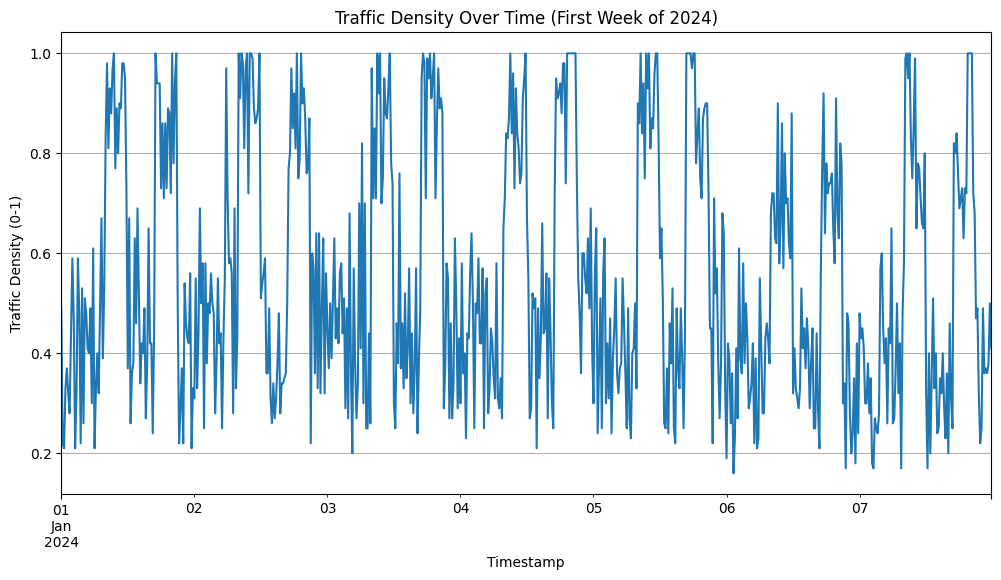

In [ ]:

# 1. Traffic Density Over Time (First Week Sample)
plt.figure(figsize=(12, 6))
df['traffic_density'].iloc[:672].plot()  # 672 = 7 days * 96 (15-min intervals)
plt.title('Traffic Density Over Time (First Week of 2024)')
plt.xlabel('Timestamp')
plt.ylabel('Traffic Density (0-1)')
plt.grid(True)
plt.show()


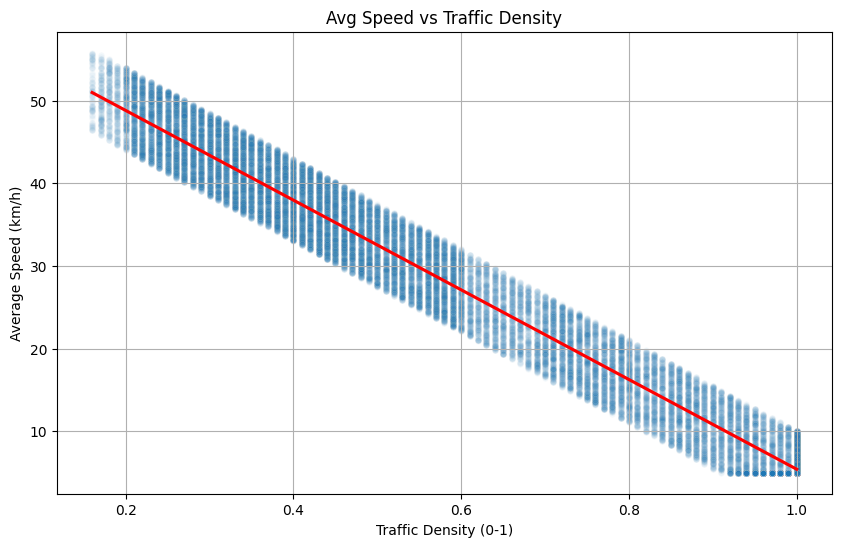

In [ ]:
# 2. Avg Speed vs Traffic Density (Improved Scatter with Trend Line)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='traffic_density', y='avg_speed', data=df, alpha=0.05, s=20)
sns.regplot(x='traffic_density', y='avg_speed', data=df, scatter=False, color='red')
plt.title('Avg Speed vs Traffic Density')
plt.xlabel('Traffic Density (0-1)')
plt.ylabel('Average Speed (km/h)')
plt.grid(True)
plt.show()

<Figure size 1000x600 with 0 Axes>

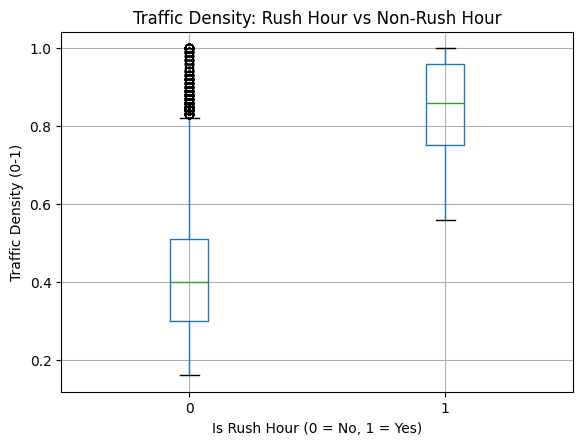

In [ ]:

# 3. Rush Hour Impact (Boxplot)
plt.figure(figsize=(10, 6))
df.boxplot(column='traffic_density', by='is_rush_hour')
plt.title('Traffic Density: Rush Hour vs Non-Rush Hour')
plt.suptitle('')  # Remove default title
plt.xlabel('Is Rush Hour (0 = No, 1 = Yes)')
plt.ylabel('Traffic Density (0-1)')
plt.show()


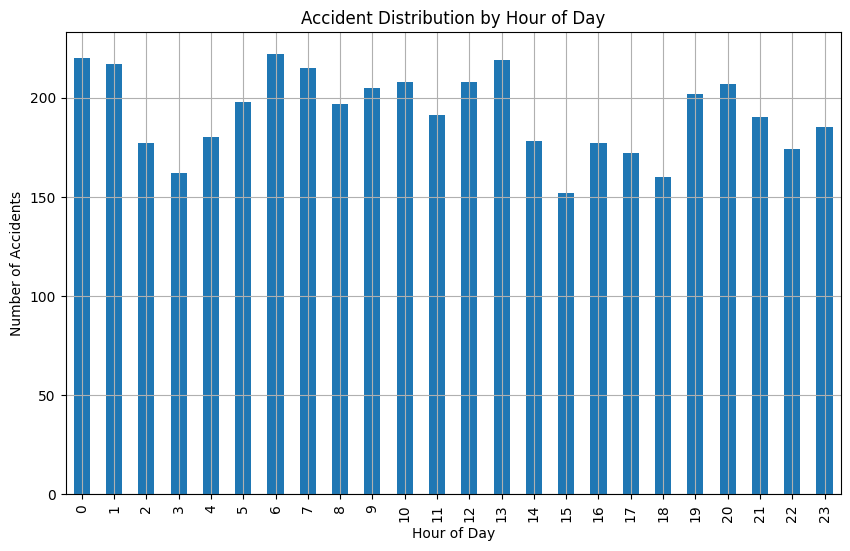

In [ ]:

# 4. Accident Distribution (Count by Hour)
plt.figure(figsize=(10, 6))
df[df['accident_flag'] == 1].index.hour.value_counts().sort_index().plot(kind='bar')
plt.title('Accident Distribution by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Accidents')
plt.grid(True)
plt.show()

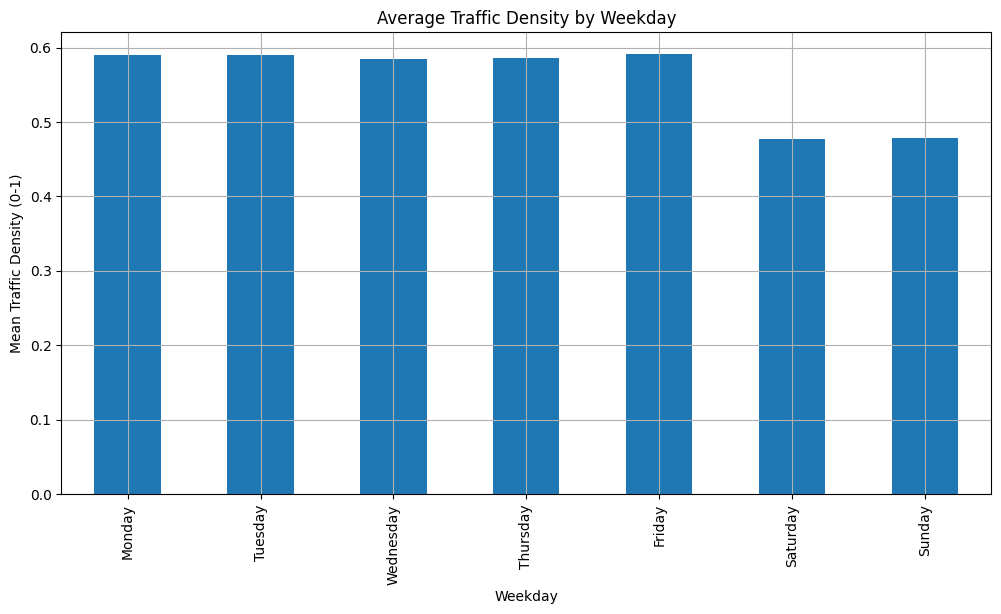

In [ ]:

# 5. Weekday Trends (Mean Density per Weekday)
plt.figure(figsize=(12, 6))
df.groupby('weekday')['traffic_density'].mean().reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
).plot(kind='bar')
plt.title('Average Traffic Density by Weekday')
plt.xlabel('Weekday')
plt.ylabel('Mean Traffic Density (0-1)')
plt.grid(True)
plt.show()



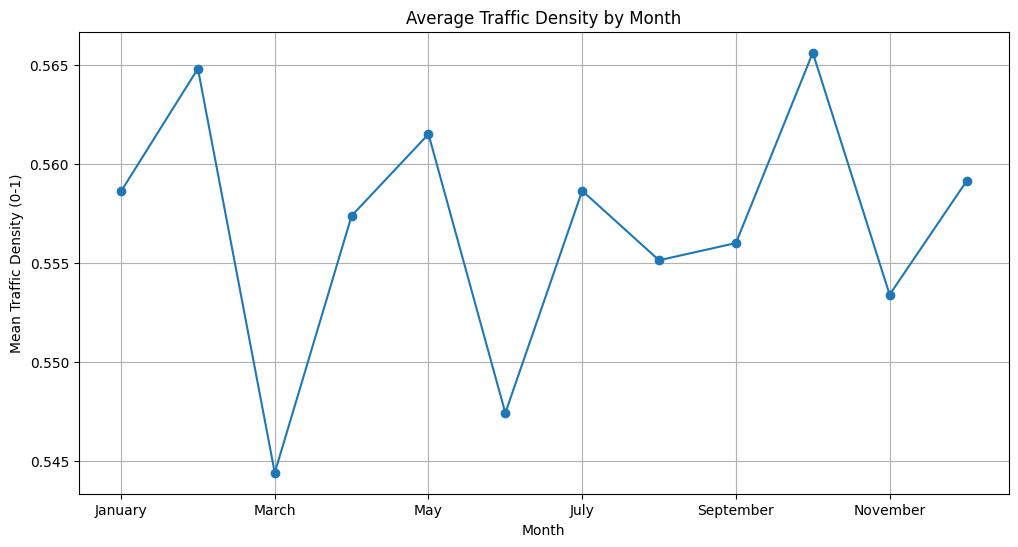

In [ ]:
# 6. Monthly Patterns (Mean Density per Month)
plt.figure(figsize=(12, 6))
df.groupby('month')['traffic_density'].mean().reindex(
    ['January', 'February', 'March', 'April', 'May', 'June',
     'July', 'August', 'September', 'October', 'November', 'December']
).plot(kind='line', marker='o')
plt.title('Average Traffic Density by Month')
plt.xlabel('Month')
plt.ylabel('Mean Traffic Density (0-1)')
plt.grid(True)
plt.show()



In [ ]:
# Basic Stats
print("\nBasic Statistics:")


df[['traffic_density', 'avg_speed', 'is_rush_hour', 'is_weekend', 'accident_flag']].describe()


Basic Statistics:


,traffic_density,avg_speed,is_rush_hour,is_weekend,accident_flag
count,35136.000000,35136.000000,35136.000000,35136.000000,35136.000000
mean,0.556842,29.461242,0.333333,0.284153,0.131375
std,0.245629,13.618221,0.471411,0.451016,0.337815
min,0.160000,5.000000,0.000000,0.000000,0.000000
25%,0.350000,17.875000,0.000000,0.000000,0.000000
50%,0.510000,32.000000,0.000000,0.000000,0.000000
75%,0.760000,40.700000,1.000000,1.000000,0.000000
max,1.000000,55.800000,1.000000,1.000000,1.000000


In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv('benz_circle_traffic_2024.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
print("Data loaded:", df.shape)

Data loaded: (35136, 12)


In [ ]:
exact_duplicates = df.duplicated().sum()
print("Number of exact duplicate rows:", exact_duplicates)

Number of exact duplicate rows: 0


In [ ]:
# 2. Check for timestamp duplicates
timestamp_duplicates = df['timestamp'].duplicated().sum()
print("Number of timestamp duplicates:", timestamp_duplicates)

Number of timestamp duplicates: 0


In [ ]:
# 3. Check for feature duplicates (excluding timestamp, junction, etc.)
feature_cols = ['traffic_density', 'avg_speed', 'is_rush_hour', 'is_weekend', 'accident_flag']
feature_duplicates = df[feature_cols].duplicated().sum()
print("Number of feature duplicates:", feature_duplicates)

Number of feature duplicates: 20121


In [ ]:
if feature_duplicates > 0:
    print("Feature duplicates found. First few duplicates:")
    print(df[df[feature_cols].duplicated()].head())

Feature duplicates found. First few duplicates:
             timestamp     junction  traffic_density weather  latitude  \
44 2024-01-01 11:00:00  Benz Circle             0.98   Sunny   16.4986   
68 2024-01-01 17:00:00  Benz Circle             1.00   Rainy   16.4986   
80 2024-01-01 20:00:00  Benz Circle             1.00   Foggy   16.4986   
83 2024-01-01 20:45:00  Benz Circle             1.00   Rainy   16.4986   
92 2024-01-01 23:00:00  Benz Circle             0.42   Sunny   16.4986   

    longitude  avg_speed  is_rush_hour  is_weekend  accident_flag weekday  \
44    80.6521        5.0             1           0              0  Monday   
68    80.6521        5.0             1           0              0  Monday   
80    80.6521        5.0             1           0              0  Monday   
83    80.6521        5.0             1           0              0  Monday   
92    80.6521       41.3             0           0              0  Monday   

      month  
44  January  
68  January  
80

In [ ]:
df[df[feature_cols].duplicated()].head()

,timestamp,junction,traffic_density,weather,latitude,longitude,avg_speed,is_rush_hour,is_weekend,accident_flag,weekday,month
44,2024-01-01 11:00:00,Benz Circle,0.98,Sunny,16.4986,80.6521,5.0,1,0,0,Monday,January
68,2024-01-01 17:00:00,Benz Circle,1.00,Rainy,16.4986,80.6521,5.0,1,0,0,Monday,January
80,2024-01-01 20:00:00,Benz Circle,1.00,Foggy,16.4986,80.6521,5.0,1,0,0,Monday,January
83,2024-01-01 20:45:00,Benz Circle,1.00,Rainy,16.4986,80.6521,5.0,1,0,0,Monday,January
92,2024-01-01 23:00:00,Benz Circle,0.42,Sunny,16.4986,80.6521,41.3,0,0,0,Monday,January


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv('benz_circle_traffic_2024.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
print("Data loaded:", df.shape)

Data loaded: (35136, 12)


In [ ]:
# Features
features = ['traffic_density', 'avg_speed', 'is_rush_hour', 'is_weekend', 'accident_flag']

In [ ]:
continuous_features = ['traffic_density', 'avg_speed']

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

In [ ]:
scalers = {feature: StandardScaler() for feature in continuous_features}

# Create a copy of the DataFrame to store scaled values
df_scaled = df.copy()

In [ ]:
scalers

{'traffic_density': StandardScaler(), 'avg_speed': StandardScaler()}

In [ ]:
import joblib

In [ ]:
# Scale each continuous feature and save the scaler
for feature in continuous_features:
    feature_values = df[[feature]].values
    scaled_values = scalers[feature].fit_transform(feature_values)
    df_scaled[feature] = scaled_values.flatten()

    # Save the scaler as a .pkl file
    scaler_filename = f'scaler_{feature}.pkl'
    joblib.dump(scalers[feature], scaler_filename)
    print(f"Saved scaler for {feature} as {scaler_filename}")

# Verify scaling
print("\nStats after scaling (binary features unchanged):")
print(df_scaled[features].describe())

Saved scaler for traffic_density as scaler_traffic_density.pkl
Saved scaler for avg_speed as scaler_avg_speed.pkl

Stats after scaling (binary features unchanged):
       traffic_density     avg_speed  is_rush_hour    is_weekend  \
count     3.513600e+04  3.513600e+04  35136.000000  35136.000000   
mean     -3.311458e-16 -1.911040e-16      0.333333      0.284153   
std       1.000014e+00  1.000014e+00      0.471411      0.451016   
min      -1.615639e+00 -1.796240e+00      0.000000      0.000000   
25%      -8.421028e-01 -8.508018e-01      0.000000      0.000000   
50%      -1.907039e-01  1.864263e-01      0.000000      0.000000   
75%       8.271067e-01  8.252853e-01      1.000000      1.000000   
max       1.804205e+00  1.934110e+00      1.000000      1.000000   

       accident_flag  
count   35136.000000  
mean        0.131375  
std         0.337815  
min         0.000000  
25%         0.000000  
50%         0.000000  
75%         0.000000  
max         1.000000  


In [ ]:
df_scaled[features].describe()

,traffic_density,avg_speed,is_rush_hour,is_weekend,accident_flag
count,3.513600e+04,3.513600e+04,35136.000000,35136.000000,35136.000000
mean,-3.311458e-16,-1.911040e-16,0.333333,0.284153,0.131375
std,1.000014e+00,1.000014e+00,0.471411,0.451016,0.337815
min,-1.615639e+00,-1.796240e+00,0.000000,0.000000,0.000000
25%,-8.421028e-01,-8.508018e-01,0.000000,0.000000,0.000000
50%,-1.907039e-01,1.864263e-01,0.000000,0.000000,0.000000
75%,8.271067e-01,8.252853e-01,1.000000,1.000000,0.000000
max,1.804205e+00,1.934110e+00,1.000000,1.000000,1.000000


In [ ]:
df_scaled.head()

,timestamp,junction,traffic_density,weather,latitude,longitude,avg_speed,is_rush_hour,is_weekend,accident_flag,weekday,month
0,2024-01-01 00:00:00,Benz Circle,-0.272129,Sunny,16.4986,80.6521,0.333290,0,0,0,Monday,January
1,2024-01-01 00:15:00,Benz Circle,-1.371364,Sunny,16.4986,80.6521,1.625695,0,0,0,Monday,January
2,2024-01-01 00:30:00,Benz Circle,-1.412077,Sunny,16.4986,80.6521,1.735843,0,0,0,Monday,January
3,2024-01-01 00:45:00,Benz Circle,-0.923528,Rainy,16.4986,80.6521,0.678421,0,0,0,Monday,January
4,2024-01-01 01:00:00,Benz Circle,-0.760678,Sunny,16.4986,80.6521,0.597646,0,0,0,Monday,January


In [ ]:
df_scaled.to_csv('benz_circle_traffic_2024_scaled.csv', index=False)
print("Scaled dataset saved as 'benz_circle_traffic_2024_scaled.csv'")

Scaled dataset saved as 'benz_circle_traffic_2024_scaled.csv'


In [ ]:
import pandas as pd
import joblib

# Load scaled dataset
df = pd.read_csv('benz_circle_traffic_2024_scaled.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
print("Scaled data loaded:", df.shape)

# Verify unique values in each column
print("\nUnique values before encoding:")
print("Weather:", df['weather'].unique())
print("Weekday:", df['weekday'].unique())
print("Month:", df['month'].unique())

Scaled data loaded: (35136, 12)

Unique values before encoding:
Weather: ['Sunny' 'Rainy' 'Foggy']
Weekday: ['Monday' 'Tuesday' 'Wednesday' 'Thursday' 'Friday' 'Saturday' 'Sunday']
Month: ['January' 'February' 'March' 'April' 'May' 'June' 'July' 'August'
 'September' 'October' 'November' 'December']


In [ ]:
# One-hot encode each column separately
# Weather
weather_encoded = pd.get_dummies(df['weather'], prefix='weather')
# Weekday
weekday_encoded = pd.get_dummies(df['weekday'], prefix='weekday')
# Month
month_encoded = pd.get_dummies(df['month'], prefix='month')

In [ ]:
df.head()

,timestamp,junction,traffic_density,weather,latitude,longitude,avg_speed,is_rush_hour,is_weekend,accident_flag,weekday,month
0,2024-01-01 00:00:00,Benz Circle,-0.272129,Sunny,16.4986,80.6521,0.333290,0,0,0,Monday,January
1,2024-01-01 00:15:00,Benz Circle,-1.371364,Sunny,16.4986,80.6521,1.625695,0,0,0,Monday,January
2,2024-01-01 00:30:00,Benz Circle,-1.412077,Sunny,16.4986,80.6521,1.735843,0,0,0,Monday,January
3,2024-01-01 00:45:00,Benz Circle,-0.923528,Rainy,16.4986,80.6521,0.678421,0,0,0,Monday,January
4,2024-01-01 01:00:00,Benz Circle,-0.760678,Sunny,16.4986,80.6521,0.597646,0,0,0,Monday,January


In [ ]:
# Concatenate the encoded columns to the DataFrame
df_encoded = pd.concat([df, weather_encoded, weekday_encoded, month_encoded], axis=1)

# Drop the original categorical columns
df_encoded = df_encoded.drop(columns=['weather', 'weekday', 'month'])

In [ ]:
df_encoded.head()

,timestamp,junction,traffic_density,latitude,longitude,avg_speed,is_rush_hour,is_weekend,accident_flag,weather_Foggy,...,month_December,month_February,month_January,month_July,month_June,month_March,month_May,month_November,month_October,month_September
0,2024-01-01 00:00:00,Benz Circle,-0.272129,16.4986,80.6521,0.333290,0,0,0,False,...,False,False,True,False,False,False,False,False,False,False
1,2024-01-01 00:15:00,Benz Circle,-1.371364,16.4986,80.6521,1.625695,0,0,0,False,...,False,False,True,False,False,False,False,False,False,False
2,2024-01-01 00:30:00,Benz Circle,-1.412077,16.4986,80.6521,1.735843,0,0,0,False,...,False,False,True,False,False,False,False,False,False,False
3,2024-01-01 00:45:00,Benz Circle,-0.923528,16.4986,80.6521,0.678421,0,0,0,False,...,False,False,True,False,False,False,False,False,False,False
4,2024-01-01 01:00:00,Benz Circle,-0.760678,16.4986,80.6521,0.597646,0,0,0,False,...,False,False,True,False,False,False,False,False,False,False


In [ ]:
# Verify the new columns
print("\nShape after encoding:", df_encoded.shape)
print("New columns added:", [col for col in df_encoded.columns if col.startswith('weather_') or col.startswith('weekday_') or col.startswith('month_')])

#


Shape after encoding: (35136, 31)
New columns added: ['weather_Foggy', 'weather_Rainy', 'weather_Sunny', 'weekday_Friday', 'weekday_Monday', 'weekday_Saturday', 'weekday_Sunday', 'weekday_Thursday', 'weekday_Tuesday', 'weekday_Wednesday', 'month_April', 'month_August', 'month_December', 'month_February', 'month_January', 'month_July', 'month_June', 'month_March', 'month_May', 'month_November', 'month_October', 'month_September']


In [ ]:
print("\nSample of encoded data:")
print(df_encoded.head())


Sample of encoded data:
            timestamp     junction  traffic_density  latitude  longitude  \
0 2024-01-01 00:00:00  Benz Circle        -0.272129   16.4986    80.6521   
1 2024-01-01 00:15:00  Benz Circle        -1.371364   16.4986    80.6521   
2 2024-01-01 00:30:00  Benz Circle        -1.412077   16.4986    80.6521   
3 2024-01-01 00:45:00  Benz Circle        -0.923528   16.4986    80.6521   
4 2024-01-01 01:00:00  Benz Circle        -0.760678   16.4986    80.6521   

   avg_speed  is_rush_hour  is_weekend  accident_flag  weather_Foggy  ...  \
0   0.333290             0           0              0          False  ...   
1   1.625695             0           0              0          False  ...   
2   1.735843             0           0              0          False  ...   
3   0.678421             0           0              0          False  ...   
4   0.597646             0           0              0          False  ...   

   month_December  month_February  month_January  month

In [ ]:
# Convert True/False to 1/0 (if not already done in CSV)
for col in df_encoded.columns:
    if df_encoded[col].dtype == 'bool':
        df_encoded[col] = df_encoded[col].astype(int)

In [ ]:
df_encoded.head()

,timestamp,junction,traffic_density,latitude,longitude,avg_speed,is_rush_hour,is_weekend,accident_flag,weather_Foggy,...,month_December,month_February,month_January,month_July,month_June,month_March,month_May,month_November,month_October,month_September
0,2024-01-01 00:00:00,Benz Circle,-0.272129,16.4986,80.6521,0.333290,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
1,2024-01-01 00:15:00,Benz Circle,-1.371364,16.4986,80.6521,1.625695,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
2,2024-01-01 00:30:00,Benz Circle,-1.412077,16.4986,80.6521,1.735843,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
3,2024-01-01 00:45:00,Benz Circle,-0.923528,16.4986,80.6521,0.678421,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
4,2024-01-01 01:00:00,Benz Circle,-0.760678,16.4986,80.6521,0.597646,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0


In [ ]:
# Create and save encoder mappings
# Weather encoder mapping
weather_categories = df['weather'].unique()
weather_mapping = {cat: f'weather_{cat}' for cat in weather_categories}
joblib.dump(weather_mapping, 'encoder_weather.pkl')
print("Saved weather encoder as 'encoder_weather.pkl'")

# Weekday encoder mapping
weekday_categories = df['weekday'].unique()
weekday_mapping = {cat: f'weekday_{cat}' for cat in weekday_categories}
joblib.dump(weekday_mapping, 'encoder_weekday.pkl')
print("Saved weekday encoder as 'encoder_weekday.pkl'")

# Month encoder mapping
month_categories = df['month'].unique()
month_mapping = {cat: f'month_{cat}' for cat in month_categories}
joblib.dump(month_mapping, 'encoder_month.pkl')
print("Saved month encoder as 'encoder_month.pkl'")

Saved weather encoder as 'encoder_weather.pkl'
Saved weekday encoder as 'encoder_weekday.pkl'
Saved month encoder as 'encoder_month.pkl'


In [ ]:
new_data.head()

,timestamp,junction,traffic_density,latitude,longitude,avg_speed,is_rush_hour,is_weekend,accident_flag,weather_Sunny,...,month_March,month_April,month_May,month_June,month_July,month_August,month_September,month_October,month_November,month_December
0,2024-01-01 00:00:00,Benz Circle,-1.615639,16.4986,80.6521,0.863263,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df_encoded.columns

Index(['timestamp', 'junction', 'traffic_density', 'latitude', 'longitude',
       'avg_speed', 'is_rush_hour', 'is_weekend', 'accident_flag',
       'weather_Foggy', 'weather_Rainy', 'weather_Sunny', 'weekday_Friday',
       'weekday_Monday', 'weekday_Saturday', 'weekday_Sunday',
       'weekday_Thursday', 'weekday_Tuesday', 'weekday_Wednesday',
       'month_April', 'month_August', 'month_December', 'month_February',
       'month_January', 'month_July', 'month_June', 'month_March', 'month_May',
       'month_November', 'month_October', 'month_September'],
      dtype='object')

In [ ]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35136 entries, 0 to 35135
Data columns (total 31 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   timestamp          35136 non-null  datetime64[ns]
 1   junction           35136 non-null  object        
 2   traffic_density    35136 non-null  float64       
 3   latitude           35136 non-null  float64       
 4   longitude          35136 non-null  float64       
 5   avg_speed          35136 non-null  float64       
 6   is_rush_hour       35136 non-null  int64         
 7   is_weekend         35136 non-null  int64         
 8   accident_flag      35136 non-null  int64         
 9   weather_Foggy      35136 non-null  int64         
 10  weather_Rainy      35136 non-null  int64         
 11  weather_Sunny      35136 non-null  int64         
 12  weekday_Friday     35136 non-null  int64         
 13  weekday_Monday     35136 non-null  int64         
 14  weekda

# dataset creation

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Fixed junction details
junction = 'Benz Circle'
lat, lon, road_type = 16.4986, 80.6521, 'Arterial'

# Time range (full 2024)
start_date = datetime(2024, 1, 1)
end_date = datetime(2024, 12, 31, 23, 45)
time_intervals = pd.date_range(start=start_date, end=end_date, freq='15min')

# Functions for data generation
def generate_traffic_density(timestamp, weather, road_type, accident_effect):
    hour, weekday = timestamp.hour, timestamp.weekday()

    if 8 <= hour <= 11 or 17 <= hour <= 20:  # Rush hour
        base_density = np.random.uniform(0.9, 1.0) if np.random.random() < 0.9 else np.random.uniform(0.7, 0.9)
    else:
        base_density = np.random.uniform(0.4, 0.9) if np.random.random() < 0.8 else np.random.uniform(0.1, 0.4)

    if weekday >= 5:
        base_density *= 0.9

    if weather == 'Rainy':
        base_density = min(base_density * 1.3, 1.0)
    elif weather == 'Foggy':
        base_density = min(base_density * 1.2, 1.0)

    if road_type == 'Highway':
        base_density *= 0.9

    if accident_effect > 0:
        base_density = min(base_density * (1 + accident_effect), 1.0)

    return round(base_density, 2)

def generate_avg_speed(traffic_density, timestamp):
    base_speed = 60 - (traffic_density * 55)
    if is_rush_hour(timestamp):
        noise = np.random.uniform(-5, 5)
    else:
        noise = np.random.uniform(5, 15)

    speed = base_speed + noise
    # Ensure speed is within bounds and not NaN
    if np.isnan(speed):
        speed = 30.0  # Default value if NaN
    speed = max(5, min(speed, 60))
    return round(speed, 1)

def assign_weather(timestamp):
    rand = np.random.random()
    return 'Sunny' if rand < 0.7 else 'Rainy' if rand < 0.9 else 'Foggy'

def is_rush_hour(timestamp):
    return 1 if 8 <= timestamp.hour <= 11 or 17 <= timestamp.hour <= 20 else 0

def is_weekend(timestamp):
    return 1 if timestamp.weekday() >= 5 else 0

# Mappings
weekday_map = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday',
               4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
month_map = {i: datetime(2024, i, 1).strftime('%B') for i in range(1, 13)}

# Data generation
data, accident_effect = [], 0
accident_duration = 8  # 2 hours (8 * 15min)
np.random.seed(42)

for timestamp in time_intervals:
    weather = assign_weather(timestamp)

    if accident_effect == 0 and np.random.random() < 0.10:
        accident_effect = 0.8

    traffic_density = generate_traffic_density(timestamp, weather, road_type, accident_effect)
    avg_speed = generate_avg_speed(traffic_density, timestamp)
    rush_hour, weekend = is_rush_hour(timestamp), is_weekend(timestamp)
    accident_flag = 1 if accident_effect > 0 else 0
    weekday, month = weekday_map[timestamp.weekday()], month_map[timestamp.month]

    # Calculate congestion score
    speed_normalized = (55.8 - avg_speed) / (55.8 - 5.0)
    if np.isnan(speed_normalized):
        speed_normalized = 0.5  # Default value if NaN
    w1, w2, w3 = 0.2, 0.4, 0.4
    score = w1 * traffic_density + w2 * speed_normalized + w3 * accident_flag
    if np.isnan(score):
        score = 0.5  # Default value if NaN

    # Adjust binning
    congestion_level = pd.cut([score], bins=[0, 0.47, 0.77, 1.0], labels=[0, 1, 2], include_lowest=True)[0]
    if pd.isna(congestion_level):
        congestion_level = 0  # Default to Low if NaN

    data.append([timestamp, junction, traffic_density, weather, lat, lon, avg_speed,
                 rush_hour, weekend, accident_flag, weekday, month, congestion_level])

    accident_effect = max(accident_effect - (0.8 / accident_duration), 0) if accident_effect > 0 else 0

# Create DataFrame
df = pd.DataFrame(data, columns=[
    'timestamp', 'junction', 'traffic_density', 'weather',
    'latitude', 'longitude', 'avg_speed', 'is_rush_hour',
    'is_weekend', 'accident_flag', 'weekday', 'month', 'Congestion_Level'])

# Save dataset
df.to_csv('benz_circle_traffic_2024_natural_balanced_final_fixed.csv', index=False)
print("Dataset saved as 'benz_circle_traffic_2024_natural_balanced_final_fixed.csv'")
print("Rows:", len(df))

# Check balance
print("\nCongestion_Level distribution:")
print(df['Congestion_Level'].value_counts(normalize=True))

# Show sample
print("\nSample of dataset:")
print(df.head())

Dataset saved as 'benz_circle_traffic_2024_natural_balanced_final_fixed.csv'
Rows: 35136

Congestion_Level distribution:
Congestion_Level
2    0.348133
0    0.345799
1    0.306068
Name: proportion, dtype: float64

Sample of dataset:
            timestamp     junction  traffic_density weather  latitude  \
0 2024-01-01 00:00:00  Benz Circle             0.70   Sunny   16.4986   
1 2024-01-01 00:15:00  Benz Circle             0.50   Sunny   16.4986   
2 2024-01-01 00:30:00  Benz Circle             0.59   Sunny   16.4986   
3 2024-01-01 00:45:00  Benz Circle             0.88   Sunny   16.4986   
4 2024-01-01 01:00:00  Benz Circle             1.00   Sunny   16.4986   

   longitude  avg_speed  is_rush_hour  is_weekend  accident_flag weekday  \
0    80.6521       28.1             0           0              0  Monday   
1    80.6521       44.6             0           0              1  Monday   
2    80.6521       34.7             0           0              1  Monday   
3    80.6521       21.8 

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Time range (2019 to 2024, 6 years)
start_date = datetime(2019, 1, 1)
end_date = datetime(2024, 12, 31, 23, 45)
time_intervals = pd.date_range(start=start_date, end=end_date, freq='15min')

# Functions for data generation
def generate_traffic_density(timestamp, weather, accident_effect):
    hour, weekday = timestamp.hour, timestamp.weekday()

    if 8 <= hour <= 11 or 17 <= hour <= 20:  # Rush hour
        base_density = np.random.uniform(0.9, 1.0) if np.random.random() < 0.9 else np.random.uniform(0.7, 0.9)
    else:
        base_density = np.random.uniform(0.4, 0.9) if np.random.random() < 0.8 else np.random.uniform(0.1, 0.4)

    if weekday >= 5:
        base_density *= 0.9

    if weather == 'Rainy':
        base_density = min(base_density * 1.3, 1.0)
    elif weather == 'Foggy':
        base_density = min(base_density * 1.2, 1.0)

    if accident_effect > 0:
        base_density = min(base_density * (1 + accident_effect), 1.0)

    return round(base_density, 2)

def generate_avg_speed(traffic_density, timestamp):
    base_speed = 60 - (traffic_density * 55)
    if is_rush_hour(timestamp):
        noise = np.random.uniform(-5, 5)
    else:
        noise = np.random.uniform(5, 15)

    speed = base_speed + noise
    if np.isnan(speed):
        speed = 30.0  # Default value if NaN
    speed = max(5, min(speed, 60))
    return round(speed, 1)

def assign_weather(timestamp):
    rand = np.random.random()
    return 'Sunny' if rand < 0.7 else 'Rainy' if rand < 0.9 else 'Foggy'

def is_rush_hour(timestamp):
    return 1 if 8 <= timestamp.hour <= 11 or 17 <= timestamp.hour <= 20 else 0

def is_weekend(timestamp):
    return 1 if timestamp.weekday() >= 5 else 0

# Mappings
weekday_map = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday',
               4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
month_map = {i: datetime(2024, i, 1).strftime('%B') for i in range(1, 13)}

# Data generation
data, accident_effect = [], 0
accident_duration = 8  # 2 hours (8 * 15min)
np.random.seed(42)

for timestamp in time_intervals:
    weather = assign_weather(timestamp)

    if accident_effect == 0 and np.random.random() < 0.10:
        accident_effect = 0.8

    traffic_density = generate_traffic_density(timestamp, weather, accident_effect)
    avg_speed = generate_avg_speed(traffic_density, timestamp)
    rush_hour, weekend = is_rush_hour(timestamp), is_weekend(timestamp)
    accident_flag = 1 if accident_effect > 0 else 0
    weekday, month = weekday_map[timestamp.weekday()], month_map[timestamp.month]
    hour_of_day = timestamp.hour
    day_of_year = timestamp.timetuple().tm_yday

    # Calculate congestion score
    speed_normalized = (55.8 - avg_speed) / (55.8 - 5.0)
    if np.isnan(speed_normalized):
        speed_normalized = 0.5  # Default value if NaN
    w1, w2, w3 = 0.2, 0.4, 0.4
    score = w1 * traffic_density + w2 * speed_normalized + w3 * accident_flag
    if np.isnan(score):
        score = 0.5  # Default value if NaN

    # Adjust binning
    congestion_level = pd.cut([score], bins=[0, 0.47, 0.77, 1.0], labels=[0, 1, 2], include_lowest=True)[0]
    if pd.isna(congestion_level):
        congestion_level = 0  # Default to Low if NaN

    data.append([timestamp, traffic_density, weather, avg_speed,
                 rush_hour, weekend, accident_flag, weekday, month,
                 hour_of_day, day_of_year, congestion_level])

    accident_effect = max(accident_effect - (0.8 / accident_duration), 0) if accident_effect > 0 else 0

# Create DataFrame
df = pd.DataFrame(data, columns=[
    'timestamp', 'traffic_density', 'weather', 'avg_speed', 'is_rush_hour',
    'is_weekend', 'accident_flag', 'weekday', 'month', 'hour_of_day',
    'day_of_year', 'Congestion_Level'])

# Save dataset
df.to_csv('traffic_2019_2024_15min_with_features.csv', index=False)
print("Dataset saved as 'traffic_2019_2024_15min_with_features.csv'")
print("Rows:", len(df))

# Check balance
print("\nCongestion_Level distribution:")
print(df['Congestion_Level'].value_counts(normalize=True))

# Show sample
print("\nSample of dataset:")
print(df.head())

#Dataset Load

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import joblib

# Load the 15-minute interval data
df = pd.read_csv('traffic_2019_2024_15min_with_features.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp')

Data loaded: (35136, 13)


In [ ]:
df.isnull().sum()

,0
timestamp,0
junction,0
traffic_density,0
weather,0
latitude,0
longitude,0
avg_speed,0
is_rush_hour,0
is_weekend,0
accident_flag,0


In [ ]:
# Resample to 30-minute intervals
df.set_index('timestamp', inplace=True)
data_30min = df.resample('30min').agg({
    'traffic_density': 'mean',
    'avg_speed': 'mean',
    'is_rush_hour': 'max',
    'is_weekend': 'max',
    'accident_flag': 'max',
    'weather': lambda x: x.mode()[0] if not x.empty else 'Sunny',
    'weekday': lambda x: x.mode()[0] if not x.empty else 'Monday',
    'month': lambda x: x.mode()[0] if not x.empty else 'January',
    'hour_of_day': 'last',  # Use the last value in the 30-minute window
    'day_of_year': 'last',  # Use the last value in the 30-minute window
    'Congestion_Level': 'last'  # Use the last value in the 30-minute window
}).reset_index()

In [ ]:
# Step 1: Scale Continuous Features
scaler_traffic_density = StandardScaler()
scaler_avg_speed = StandardScaler()
scaler_hour_of_day = StandardScaler()
scaler_day_of_year = StandardScaler()

data_30min['traffic_density'] = scaler_traffic_density.fit_transform(data_30min[['traffic_density']])
data_30min['avg_speed'] = scaler_avg_speed.fit_transform(data_30min[['avg_speed']])
data_30min['hour_of_day'] = scaler_hour_of_day.fit_transform(data_30min[['hour_of_day']])
data_30min['day_of_year'] = scaler_day_of_year.fit_transform(data_30min[['day_of_year']])

In [ ]:
# Save scalers for prediction
joblib.dump(scaler_traffic_density, 'scaler_traffic_density_30min.pkl')
joblib.dump(scaler_avg_speed, 'scaler_avg_speed_30min.pkl')
joblib.dump(scaler_hour_of_day, 'scaler_hour_of_day_30min.pkl')
joblib.dump(scaler_day_of_year, 'scaler_day_of_year_30min.pkl')

In [ ]:
# Step 2: One-Hot Encode Categorical Features
weather_encoded = pd.get_dummies(data_30min['weather'], prefix='weather')
weekday_encoded = pd.get_dummies(data_30min['weekday'], prefix='weekday')
month_encoded = pd.get_dummies(data_30min['month'], prefix='month')

# Save unique values for encoders (for prediction)
joblib.dump(data_30min['weather'].unique(), 'encoder_weather_30min.pkl')
joblib.dump(data_30min['weekday'].unique(), 'encoder_weekday_30min.pkl')
joblib.dump(data_30min['month'].unique(), 'encoder_month_30min.pkl')

# Combine all features
data_30min = pd.concat([data_30min, weather_encoded, weekday_encoded, month_encoded], axis=1)

# Step 3: Define Features List (now 29 features with hour_of_day and day_of_year)
features = ['traffic_density', 'avg_speed', 'is_rush_hour', 'is_weekend', 'accident_flag',
            'hour_of_day', 'day_of_year',
            'weather_Foggy', 'weather_Rainy', 'weather_Sunny',
            'weekday_Friday', 'weekday_Monday', 'weekday_Saturday', 'weekday_Sunday',
            'weekday_Thursday', 'weekday_Tuesday', 'weekday_Wednesday',
            'month_April', 'month_August', 'month_December', 'month_February', 'month_January',
            'month_July', 'month_June', 'month_March', 'month_May', 'month_November',
            'month_October', 'month_September']

In [ ]:
# Verify all features exist in the DataFrame
missing_features = [f for f in features if f not in data_30min.columns]
if missing_features:
    raise ValueError(f"Missing features in DataFrame: {missing_features}")

# Step 4: Create Sequences
sequence_length = 6  # 3 hours / 30 minutes = 6 timesteps
prediction_length = 4  # 2 hours / 30 minutes = 4 timesteps
X, y = [], []

data_array = data_30min[features].to_numpy()
labels = data_30min['Congestion_Level'].to_numpy()

for i in range(len(data_array) - sequence_length - prediction_length + 1):
    X.append(data_array[i:i + sequence_length])
    y.append(labels[i + sequence_length:i + sequence_length + prediction_length])

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int32)

In [ ]:
# Step 5: Verify Shapes and Data
print("X shape:", X.shape)  # Expected: (samples, 6, 29)
print("y shape:", y.shape)  # Expected: (samples, 4)
print("X dtype:", X.dtype)
print("y dtype:", y.dtype)
print("Unique values in y:", np.unique(y))
print("NaN values in X:", np.any(np.isnan(X)))
print("NaN values in y:", np.any(np.isnan(y)))

# Step 6: Save Sequences
np.save('X_2019_2024_30min_with_features.npy', X)
np.save('y_2019_2024_30min_with_features.npy', y)
print("Saved sequences as 'X_2019_2024_30min_with_features.npy' and 'y_2019_2024_30min_with_features.npy'")

In [ ]:
df.to_csv('benz_circle_traffic_2024_final_fixed.csv', index=False)

In [ ]:
# Scale continuous features
continuous_features = ['traffic_density', 'avg_speed']
scalers = {feature: StandardScaler() for feature in continuous_features}

for feature in continuous_features:
    feature_values = df[[feature]].values
    scaled_values = scalers[feature].fit_transform(feature_values)
    df[feature] = scaled_values.flatten()
    scaler_filename = f'scaler_{feature}.pkl'
    joblib.dump(scalers[feature], scaler_filename)
    print(f"Saved scaler for {feature} as {scaler_filename}")

Saved scaler for traffic_density as scaler_traffic_density.pkl
Saved scaler for avg_speed as scaler_avg_speed.pkl


In [ ]:

# One-hot encode categorical features and ensure numeric type
weather_encoded = pd.get_dummies(df['weather'], prefix='weather').astype('float32')
weekday_encoded = pd.get_dummies(df['weekday'], prefix='weekday').astype('float32')
month_encoded = pd.get_dummies(df['month'], prefix='month').astype('float32')
df = pd.concat([df, weather_encoded, weekday_encoded, month_encoded], axis=1)

# Save encoder mappings
weather_mapping = {cat: f'weather_{cat}' for cat in df['weather'].unique()}
weekday_mapping = {cat: f'weekday_{cat}' for cat in df['weekday'].unique()}
month_mapping = {cat: f'month_{cat}' for cat in df['month'].unique()}
joblib.dump(weather_mapping, 'encoder_weather.pkl')
joblib.dump(weekday_mapping, 'encoder_weekday.pkl')
joblib.dump(month_mapping, 'encoder_month.pkl')
print("Saved encoders: encoder_weather.pkl, encoder_weekday.pkl, encoder_month.pkl")

Saved encoders: encoder_weather.pkl, encoder_weekday.pkl, encoder_month.pkl


In [ ]:
# Drop unwanted features
unwanted_features = ['junction', 'latitude', 'longitude', 'timestamp', 'weather', 'weekday', 'month']
df_final = df.drop(columns=unwanted_features)

In [ ]:
# Ensure all columns are numeric and cast to float32
numeric_columns = ['traffic_density', 'avg_speed', 'is_rush_hour', 'is_weekend', 'accident_flag']
for col in numeric_columns:
    df_final[col] = df_final[col].astype('float32')

# Ensure Congestion_Level is int32
df_final['Congestion_Level'] = df_final['Congestion_Level'].astype('int32')

In [ ]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35136 entries, 0 to 35135
Data columns (total 28 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   traffic_density    35136 non-null  float32
 1   avg_speed          35136 non-null  float32
 2   is_rush_hour       35136 non-null  float32
 3   is_weekend         35136 non-null  float32
 4   accident_flag      35136 non-null  float32
 5   Congestion_Level   35136 non-null  int32  
 6   weather_Foggy      35136 non-null  float32
 7   weather_Rainy      35136 non-null  float32
 8   weather_Sunny      35136 non-null  float32
 9   weekday_Friday     35136 non-null  float32
 10  weekday_Monday     35136 non-null  float32
 11  weekday_Saturday   35136 non-null  float32
 12  weekday_Sunday     35136 non-null  float32
 13  weekday_Thursday   35136 non-null  float32
 14  weekday_Tuesday    35136 non-null  float32
 15  weekday_Wednesday  35136 non-null  float32
 16  month_April        351

In [ ]:
# Verify
print("\nShape after processing:", df_final.shape)
print("Remaining columns:", df_final.columns.tolist())

# Save
df_final.to_csv('benz_circle_traffic_2024_final_preprocessed_fixed.csv', index=False)
print("Final dataset saved as 'benz_circle_traffic_2024_final_preprocessed_fixed.csv'")


Shape after processing: (35136, 28)
Remaining columns: ['traffic_density', 'avg_speed', 'is_rush_hour', 'is_weekend', 'accident_flag', 'Congestion_Level', 'weather_Foggy', 'weather_Rainy', 'weather_Sunny', 'weekday_Friday', 'weekday_Monday', 'weekday_Saturday', 'weekday_Sunday', 'weekday_Thursday', 'weekday_Tuesday', 'weekday_Wednesday', 'month_April', 'month_August', 'month_December', 'month_February', 'month_January', 'month_July', 'month_June', 'month_March', 'month_May', 'month_November', 'month_October', 'month_September']
Final dataset saved as 'benz_circle_traffic_2024_final_preprocessed_fixed.csv'


In [ ]:
import pandas as pd
import numpy as np

# Load final dataset
df_final = pd.read_csv('benz_circle_traffic_2024_final_preprocessed_fixed.csv')
print("Final data loaded:", df_final.shape)

# Features (exclude Congestion_Level)
features = ['traffic_density', 'avg_speed', 'is_rush_hour', 'is_weekend', 'accident_flag',
            'weather_Foggy', 'weather_Rainy', 'weather_Sunny',
            'weekday_Friday', 'weekday_Monday', 'weekday_Saturday', 'weekday_Sunday',
            'weekday_Thursday', 'weekday_Tuesday', 'weekday_Wednesday',
            'month_April', 'month_August', 'month_December', 'month_February', 'month_January',
            'month_July', 'month_June', 'month_March', 'month_May', 'month_November',
            'month_October', 'month_September']

Final data loaded: (35136, 28)


In [ ]:
# Convert to NumPy array
data_array = data_30min[features].to_numpy()
labels = data_30min['Congestion_Level'].to_numpy()

In [ ]:
# Create sequences (12 past, 8 future)
X, y = [], []
for i in range(len(df_final) - 19):
    X.append(df_final[features].iloc[i:i+12].values)
    future_congestion = df_final['Congestion_Level'].iloc[i+12:i+20].values
    y.append(future_congestion)


In [ ]:
X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int32)
print("X shape:", X.shape)
print("y shape:", y.shape)
print("X dtype:", X.dtype)
print("y dtype:", y.dtype)

In [ ]:
#Save
np.save('X_2024_preprocessed_final_fixed.npy', X)
np.save('y_2024_preprocessed_final_fixed.npy', y)
print("Saved X_2024_preprocessed_final_fixed.npy and y_2024_preprocessed_final_fixed.npy")

In [ ]:
# # Class distribution of target
# y_flat = y.flatten()
# class_dist = pd.Series(y_flat).value_counts(normalize=True)
# print("Class Distribution of Target (Congestion_Level) in y:")
# print(class_dist)

Class Distribution of Target (Congestion_Level) in y:
2    0.348147
0    0.345808
1    0.306045
Name: proportion, dtype: float64


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, RepeatVector, TimeDistributed, Layer
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, f1_score
import pickle

In [ ]:
# Load sequences
X = np.load('X_2019_2024_30min_with_features.npy')
y = np.load('y_2019_2024_30min_with_features.npy')
print("Loaded X shape:", X.shape)
print("Loaded y shape:", y.shape)
print("X dtype:", X.dtype)
print("y dtype:", y.dtype)
print("Unique values in y:", np.unique(y))
print("NaN values in y:", np.any(np.isnan(y)))

Loaded X shape: (35117, 12, 27)
Loaded y shape: (35117, 8)


In [ ]:
# Verify y contains only valid class indices
print("Unique values in y:", np.unique(y))
print("NaN values in y:", np.any(np.isnan(y)))

Unique values in y: [0 1 2]
NaN values in y: False


In [ ]:
# # Convert y to one-hot encoding for multi-class classification
# y_one_hot = np.array([to_categorical(y[i], num_classes=3) for i in range(y.shape[0])])
# print("y_one_hot shape:", y_one_hot.shape)

y_one_hot shape: (35117, 8, 3)


In [ ]:
# Compute class weights (adjust to focus more on Moderate and High)
y_flat = y.flatten()
class_counts = pd.Series(y_flat).value_counts()
total_samples = len(y_flat)
class_weights = {0: total_samples / (3 * class_counts[0]) * 0.8,  # Reduce weight for Low
                 1: total_samples / (3 * class_counts[1]) * 1.1,  # Increase weight for Moderate
                 2: total_samples / (3 * class_counts[2]) * 1.1}  # Increase weight for High
print("Class weights for training:", class_weights)

Class weights for training: {0: np.float64(0.9639252015783153), 1: np.float64(1.0891651837464187), 2: np.float64(0.9574502165829984)}


In [ ]:
# Save class weights
with open('class_weights_30min_with_features.pkl', 'wb') as f:
    pickle.dump(class_weights, f)
print("Saved class weights as 'class_weights_30min_with_features.pkl'")

Saved class weights as 'class_weights_fixed.pkl'


In [ ]:
# Split data: 70% train, 15% validation, 15% test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42, shuffle=False)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, random_state=42, shuffle=False)
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)
print("y_test shape:", y_test.shape)

X_train shape: (24580, 12, 27)
X_val shape: (5269, 12, 27)
X_test shape: (5268, 12, 27)
y_train shape: (24580, 8)
y_val shape: (5269, 8)
y_test shape: (5268, 8)


In [ ]:
# Custom Attention Layer
class AttentionLayer(Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name='attention_weight', shape=(input_shape[-1], 1), initializer='random_normal', trainable=True)
        self.b = self.add_weight(name='attention_bias', shape=(input_shape[1], 1), initializer='zeros', trainable=True)
        super(AttentionLayer, self).build(input_shape)

    def call(self, inputs):
        e = tf.keras.backend.tanh(tf.keras.backend.dot(inputs, self.W) + self.b)
        alpha = tf.keras.backend.softmax(e, axis=1)
        context = inputs * alpha
        context = tf.keras.backend.sum(context, axis=1)
        return context

    def get_config(self):
        config = super(AttentionLayer, self).get_config()
        return config


In [ ]:
# Define class weights tensor for custom loss
class_weights_tensor = tf.constant([class_weights[0], class_weights[1], class_weights[2]], dtype=tf.float32)

# Custom loss function with class weights
def weighted_sparse_categorical_crossentropy(y_true, y_pred):
    y_true = tf.cast(y_true, tf.int32)
    loss = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred, from_logits=False)
    weights = tf.gather(class_weights_tensor, y_true)
    weighted_loss = loss * weights
    return weighted_loss

In [ ]:
# Build LSTM model with increased capacity
model = Sequential([
    # First LSTM: Process 6 input timesteps
    LSTM(256, input_shape=(6, 29), return_sequences=True),  # Increased to 256 units
    Dropout(0.2),  # Increased dropout
    # Second LSTM: Return sequences for attention
    LSTM(128, return_sequences=True),  # Increased to 128 units
    Dropout(0.2),
    # Attention layer
    AttentionLayer(),
    # Repeat the vector 4 times to match the 4 future timesteps
    RepeatVector(4),
    # Third LSTM: Generate a sequence of 4 timesteps
    LSTM(128, return_sequences=True),  # Increased to 128 units
    Dropout(0.2),
    # Apply Dense layers to each timestep
    TimeDistributed(Dense(64, activation='relu')),  # Increased to 64 units
    TimeDistributed(Dense(3, activation='softmax'))
])

In [ ]:
# Compile model with custom loss and a different learning rate
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss=weighted_sparse_categorical_crossentropy, metrics=['accuracy'])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                        │ (None, 12, 64)              │          23,552 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 12, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_5 (LSTM)                        │ (None, 12, 32)              │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 12, 32)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 12, 16)              │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 12, 3)               │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 36,547 (142.76 KB)

 Trainable params: 36,547 (142.76 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=0.00001)

In [ ]:
# Train model
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

In [ ]:
# Evaluate on test set
y_test_pred = model.predict(X_test)
y_test_pred_classes = np.argmax(y_test_pred, axis=-1)
y_test_true_classes = y_test

X_train dtype: object
y_train dtype: int64
X_val dtype: object
y_val dtype: int64


In [ ]:
# Flatten for classification report
y_test_true_flat = y_test_true_classes.flatten()
y_test_pred_flat = y_test_pred_classes.flatten()

Preprocessed dataset dtypes:
traffic_density      float64
avg_speed            float64
is_rush_hour           int64
is_weekend             int64
accident_flag          int64
Congestion_Level       int64
weather_Foggy           bool
weather_Rainy           bool
weather_Sunny           bool
weekday_Friday          bool
weekday_Monday          bool
weekday_Saturday        bool
weekday_Sunday          bool
weekday_Thursday        bool
weekday_Tuesday         bool
weekday_Wednesday       bool
month_April             bool
month_August            bool
month_December          bool
month_February          bool
month_January           bool
month_July              bool
month_June              bool
month_March             bool
month_May               bool
month_November          bool
month_October           bool
month_September         bool
dtype: object

Non-numeric columns:
Index([], dtype='object')


In [ ]:
# Classification report
print("\nClassification Report on Test Set:")
print(classification_report(y_test_true_flat, y_test_pred_flat, target_names=['Low (0)', 'Moderate (1)', 'High (2)']))


In [ ]:
# Macro F1-score
f1 = f1_score(y_test_true_flat, y_test_pred_flat, average='macro')
print("Macro F1-score on Test Set:", f1)

In [ ]:
# Save model
model.save('lstm_traffic_model_30min_with_features.h5')
print("Model saved as 'lstm_traffic_model_30min_with_features.h5'")